In [2]:
# [1. 도구 상자 준비]
# - 쓰임새: 데이터 분석(Pandas), 수치 계산(NumPy), 시각화(Matplotlib/Seaborn), 머신러닝 모델들을 불러옵니다.
# - 적용이유: 요리를 시작하기 전 필요한 조리 도구와 양념들을 미리 선반에 꺼내두는 작업과 같습니다.
# - 변경내용: 파이썬이 데이터 분석 및 7종의 머신러닝 알고리즘을 사용할 수 있는 상태가 됩니다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

In [3]:
# [2. 데이터 로드 및 이름표 설정]
# - 쓰임새: 이름표 없는 txt 데이터를 불러오고 '엔진 번호', '가동 시간', '센서 1~21' 등의 이름을 붙여줍니다.
# - 적용이유: 원본 데이터는 숫자만 나열되어 있어, 어떤 열이 온도인지 압력인지 구분하기 위해 이름표가 필수입니다.
# - 변경내용: 단순한 텍스트 파일이 우리가 읽을 수 있는 '엑셀 형태의 표(DataFrame)'로 바뀝니다.

index_names = ['unit_number', 'time_in_cycles']
setting_names = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

In [4]:
# [3. 데이터 파일 불러오기]
# - 쓰임새: PC에 저장된 txt 파일을 분석 도구로 읽어와 '가상의 엑셀 표' 형태로 메모리에 올립니다.
# - 적용이유: 하드디스크에 잠자고 있는 텍스트 데이터를 분석 가능한 디지털 데이터로 변환하기 위함입니다.
# - 변경내용: 
#   - sep='\s+': 공백으로 구분된 글자들을 표의 칸으로 나눕니다.
#   - names=col_names: 앞서 만든 이름표를 데이터 머리에 붙여 '구조화된 표(DataFrame)'가 완성됩니다.

train_df = pd.read_csv(r"C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\train_FD001.txt",sep='\s+',header=None,index_col=False,names=col_names)
test_df = pd.read_csv(r"C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\test_FD001.txt",sep='\s+',header=None,index_col=False,names=col_names)
rul_df = pd.read_csv(r"C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\RUL_FD001.txt",sep='\s+',header=None,index_col=False,names=['RUL'])

In [5]:
# [4. 데이터 품질 확인 및 통계 분석]
# - 쓰임새: .head()로 상위 10개 데이터를 보고, .describe()로 평균/최솟값/최댓값 등 통계를 확인합니다.
# - 적용이유: 데이터가 깨지지는 않았는지, 혹은 값이 전혀 변하지 않는 고장 난 센서가 있는지 분석 전 '사전 검사'를 하는 과정입니다.
# - 변경내용: 분석가가 데이터의 전체적인 크기와 숫자 범위를 파악하게 됩니다.

train_df.head(10)

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [6]:
# [5. 도메인 지식 기반 컬럼명 변경]
# - 쓰임새: 'sensor_2' 같은 기계적인 이름을 'T24 (저압 압축기 온도)'처럼 물리적 의미가 담긴 이름으로 바꿉니다.
# - 적용이유: 나중에 인공지능이 "어떤 센서가 가장 중요한가요?"라고 답했을 때, 분석가가 "아, 온도가 중요하군요!"라고 바로 해석하기 위함입니다.
# - 변경내용: 모델의 해석력이 높아지며, 비전공자나 현장 전문가도 이해할 수 있는 '직관적인 표'가 됩니다.

rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,0.0_0.0_100.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,0.0_0.0_100.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,0.0_0.0_100.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,0.0_0.0_100.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,0.0_0.0_100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,0.0_0.0_100.0
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,0.0_0.0_100.0
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,0.0_0.0_100.0
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,0.0_0.0_100.0


In [7]:
# [6. 파생 변수 생성 (도메인 지식 기반)]
# - 쓰임새: 엔진의 효율이나 상태를 나타내는 새로운 지표(예: 온도비, 연료 유량)를 계산합니다.
# - 적용이유: 원본 데이터만으로는 파악하기 어려운 엔진의 '건강 상태'를 숫자로 변환하여 모델이 학습할 수 있게 돕습니다.
# - 변경내용: 데이터프레임 우측에 새로운 계산된 컬럼들이 추가됩니다.

# 1. 안전한 계산 함수 (컬럼이 있을 때만 계산)
def safe_div(col1, col2, new_col):
    if col1 in train_df.columns and col2 in train_df.columns:
        train_df[new_col] = train_df[col1] / train_df[col2]
        return True
    return False

# 2. 가능한 조합들만 계산
# LPC 온도비 (T24 / T2) -> T2가 없으면 생략됨
safe_div('T24[R]', 'T2[R]', 'LPC.TR[-]')

# HPC 온도비 (T30 / T24)
safe_div('T30[R]', 'T24[R]', 'HPC.TR[-]')

# 연료 유량 (phi * Ps30)
if 'phi[pph/psi]' in train_df.columns and 'Ps30[psi]' in train_df.columns:
    train_df["Wf[pph]"] = train_df["phi[pph/psi]"] * train_df["Ps30[psi]"]

# 보정된 연료 유량 (T2[R]이 리스트에 없으므로 생략하거나 다른 값 기준)
if 'phi[pph/psi]' in train_df.columns and 'T2[R]' in train_df.columns:
    train_df["WfP3C[pph/psi]"] = train_df["phi[pph/psi]"] / np.sqrt(train_df["T2[R]"] / 518.67)

# 3. 결측치 및 무한대 처리
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
train_df = train_df.bfill().ffill()

print(f"✅ 사용 가능한 컬럼으로 파생 변수 생성을 완료했습니다!")
print(f"📊 최종 컬럼 수: {len(train_df.columns)}개")

✅ 사용 가능한 컬럼으로 파생 변수 생성을 완료했습니다!
📊 최종 컬럼 수: 31개


In [8]:
# [7. 데이터 품질 확인 및 통계 분석]
# - 쓰임새: .head()로 상위 10개 데이터를 보고, .describe()로 평균/최솟값/최댓값 등 통계를 확인합니다.
# - 적용이유: 데이터가 깨지지는 않았는지, 혹은 값이 전혀 변하지 않는 고장 난 센서가 있는지 분석 전 '사전 검사'를 하는 과정입니다.
# - 변경내용: 분석가가 데이터의 전체적인 크기와 숫자 범위를 파악하게 됩니다.

train_df.describe()

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],LPC.TR[-],HPC.TR[-],Wf[pph],WfP3C[pph/psi]
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,1.239094,2.474822,24788.438631,47.541168
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251,0.000964,0.008518,111.059960,0.267087
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,1.236258,2.444552,24479.455000,46.850000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,1.238408,2.468961,24708.848550,47.350000
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,1.239015,2.474444,24778.261600,47.510000
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,1.239709,2.480312,24857.587350,47.700000
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,1.242659,2.513266,25233.796400,48.530000


In [9]:
# [8. 결측치 및 이상치 처리]
# - 쓰임새: 데이터에 비어있는 값(NaN)이나 비정상적인 값(무한대 등)을 제거하거나 채웁니다.
# - 적용이유: 모델이 엉뚱한 값을 학습하지 않도록 데이터를 '깨끗하게' 정제하는 필수 과정입니다.
# - 변경내용: 결측치가 제거되거나 대체되어 데이터의 행 수가 줄어들거나 값이 수정됩니다.

train_df.isnull().sum()

unit_number       0
time_in_cycles    0
Alt[kft]          0
Mn[-]             0
TLA[deg]          0
T2[R]             0
T24[R]            0
T30[R]            0
T50[R]            0
P2[psi]           0
P15[psi]          0
P30[psi]          0
Nf[rpm]           0
Nc[rpm]           0
epr[-]            0
phi[pph/psi]      0
Ps30[psi]         0
NRf[rpm]          0
NRc[rpm]          0
BPR[-]            0
farB[-]           0
htBleed[]         0
Nf_dmd[rpm]       0
PCNfR_dmd[Pct]    0
W31[lbm/s]        0
W32[lbm/s]        0
condition         0
LPC.TR[-]         0
HPC.TR[-]         0
Wf[pph]           0
WfP3C[pph/psi]    0
dtype: int64

In [10]:
# [9. 데이터프레임의 컬럼 정보 확인]
# - 쓰임새: 데이터프레임의 컬럼 이름, 데이터 타입, 결측치 개수 등을 한눈에 확인합니다.
# - 적용이유: 데이터의 구조를 파악하고 결측치가 있는지 확인하여 전처리 계획을 세우는 데 도움을 줍니다.
# - 변경내용: 데이터프레임의 컬럼 정보가 요약된 표가 생성됩니다.

pd.set_option('display.max_rows', None)
summary_df = pd.DataFrame(train_df.dtypes, columns=['Data Type'])
summary_df = summary_df.reset_index()
summary_df = summary_df.rename(columns={'index': 'Column Name'})
summary_df['Non-Null Count'] = train_df.count().values
summary_df['Null Count'] = train_df.isnull().sum().values
summary_df['Null Ratio (%)'] = (train_df.isnull().sum().values / len(train_df)) * 100
summary_df

,Column Name,Data Type,Non-Null Count,Null Count,Null Ratio (%)
0,unit_number,int64,20631,0,0.0
1,time_in_cycles,int64,20631,0,0.0
2,Alt[kft],float64,20631,0,0.0
3,Mn[-],float64,20631,0,0.0
4,TLA[deg],float64,20631,0,0.0
5,T2[R],float64,20631,0,0.0
6,T24[R],float64,20631,0,0.0
7,T30[R],float64,20631,0,0.0
8,T50[R],float64,20631,0,0.0
9,P2[psi],float64,20631,0,0.0


### 컬럼 설명 (Data Dictionary)

| 컬럼명 | 설명 | 타입 |
|---|---|---|
| **unit_number** | 엔진 고유 식별자 (Unit Number) | int64 |
| **time_in_cycles** | 운전 사이클 (Time in Cycles) | int64 |
| **Alt[kft]** | 고도 (Altitude) | float64 |
| **Mn[-]** | 마하 수 (Mach Number) | float64 |
| **TLA[deg]** | 스로틀 레버 각도 (Thrust Lever Angle) | float64 |
| **T2[R]** | 팬 입구 전온도 (Total temperature at fan inlet) | float64 |
| **T24[R]** | LPC 출구 전온도 (Total temperature at LPC outlet) | float64 |
| **T30[R]** | HPC 출구 전온도 (Total temperature at HPC outlet) | float64 |
| **T50[R]** | LPT 출구 전온도 (Total temperature at LPT outlet) | float64 |
| **P2[psi]** | 팬 입구 압력 (Pressure at fan inlet) | float64 |
| **P15[psi]** | 바이패스 덕트 전압력 (Total pressure in bypass-duct) | float64 |
| **P30[psi]** | HPC 출구 전압력 (Total pressure at HPC outlet) | float64 |
| **Nf[rpm]** | 물리적 팬 속도 (Physical fan speed) | float64 |
| **Nc[rpm]** | 물리적 코어 속도 (Physical core speed) | float64 |
| **epr[-]** | 엔진 압력비 (Engine pressure ratio) | float64 |
| **phi[pph/psi]** | 연료 유량 대 Ps30 비율 (Ratio of fuel flow to Ps30) | float64 |
| **Ps30[psi]** | HPC 출구 정압 (Static pressure at HPC outlet) | float64 |
| **NRf[rpm]** | 보정된 팬 속도 (Corrected fan speed) | float64 |
| **NRc[rpm]** | 보정된 코어 속도 (Corrected core speed) | float64 |
| **BPR[-]** | 바이패스 비 (Bypass Ratio) | float64 |
| **farB[-]** | 연소기 연료-공기 비 (Burner fuel-air ratio) | float64 |
| **htBleed[]** | 블리드 엔탈피 (Bleed Enthalpy) | int64 |
| **Nf_dmd[rpm]** | 요구 팬 속도 (Demanded fan speed) | int64 |
| **PCNfR_dmd[Pct]** | 요구 보정 팬 속도 (Demanded corrected fan speed) | float64 |
| **W31[lbm/s]** | HPT 냉각 블리드 (HPT coolant bleed) | float64 |
| **W32[lbm/s]** | LPT 냉각 블리드 (LPT coolant bleed) | float64 |
| **condition** | 운전 조건 문자열 (Operational Condition String) | object |

* 참고
| **RUL** | 엔진의 남은 수명 (Remaining Useful Life) | int64 |

In [ ]:
# [10. 컬럼별 데이터 타입 확인]
# - 쓰임새: 데이터프레임의 컬럼 이름, 데이터 타입, 결측치 개수 등을 한눈에 확인합니다.
# - 적용이유: 데이터의 구조를 파악하고 결측치가 있는지 확인하여 전처리 계획을 세우는 데 도움을 줍니다.
# - 변경내용: 데이터프레임의 컬럼 정보가 요약된 표가 생성됩니다.

train_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   Alt[kft]        20631 non-null  float64
 3   Mn[-]           20631 non-null  float64
 4   TLA[deg]        20631 non-null  float64
 5   T2[R]           20631 non-null  float64
 6   T24[R]          20631 non-null  float64
 7   T30[R]          20631 non-null  float64
 8   T50[R]          20631 non-null  float64
 9   P2[psi]         20631 non-null  float64
 10  P15[psi]        20631 non-null  float64
 11  P30[psi]        20631 non-null  float64
 12  Nf[rpm]         20631 non-null  float64
 13  Nc[rpm]         20631 non-null  float64
 14  epr[-]          20631 non-null  float64
 15  phi[pph/psi]    20631 non-null  float64
 16  Ps30[psi]       20631 non-null  float64
 17  NRf[rpm]        20631 non-null 

In [12]:
# [11. 데이터프레임의 컬럼 정보 확인]
# - 쓰임새: 데이터프레임의 컬럼 이름, 데이터 타입, 결측치 개수 등을 한눈에 확인합니다.
# - 적용이유: 데이터의 구조를 파악하고 결측치가 있는지 확인하여 전처리 계획을 세우는 데 도움을 줍니다.
# - 변경내용: 데이터프레임의 컬럼 정보가 요약된 표가 생성됩니다.

train_df.columns

Index(['unit_number', 'time_in_cycles', 'Alt[kft]', 'Mn[-]', 'TLA[deg]',
       'T2[R]', 'T24[R]', 'T30[R]', 'T50[R]', 'P2[psi]', 'P15[psi]',
       'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 'epr[-]', 'phi[pph/psi]', 'Ps30[psi]',
       'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 'farB[-]', 'htBleed[]', 'Nf_dmd[rpm]',
       'PCNfR_dmd[Pct]', 'W31[lbm/s]', 'W32[lbm/s]', 'condition', 'LPC.TR[-]',
       'HPC.TR[-]', 'Wf[pph]', 'WfP3C[pph/psi]'],
      dtype='object')

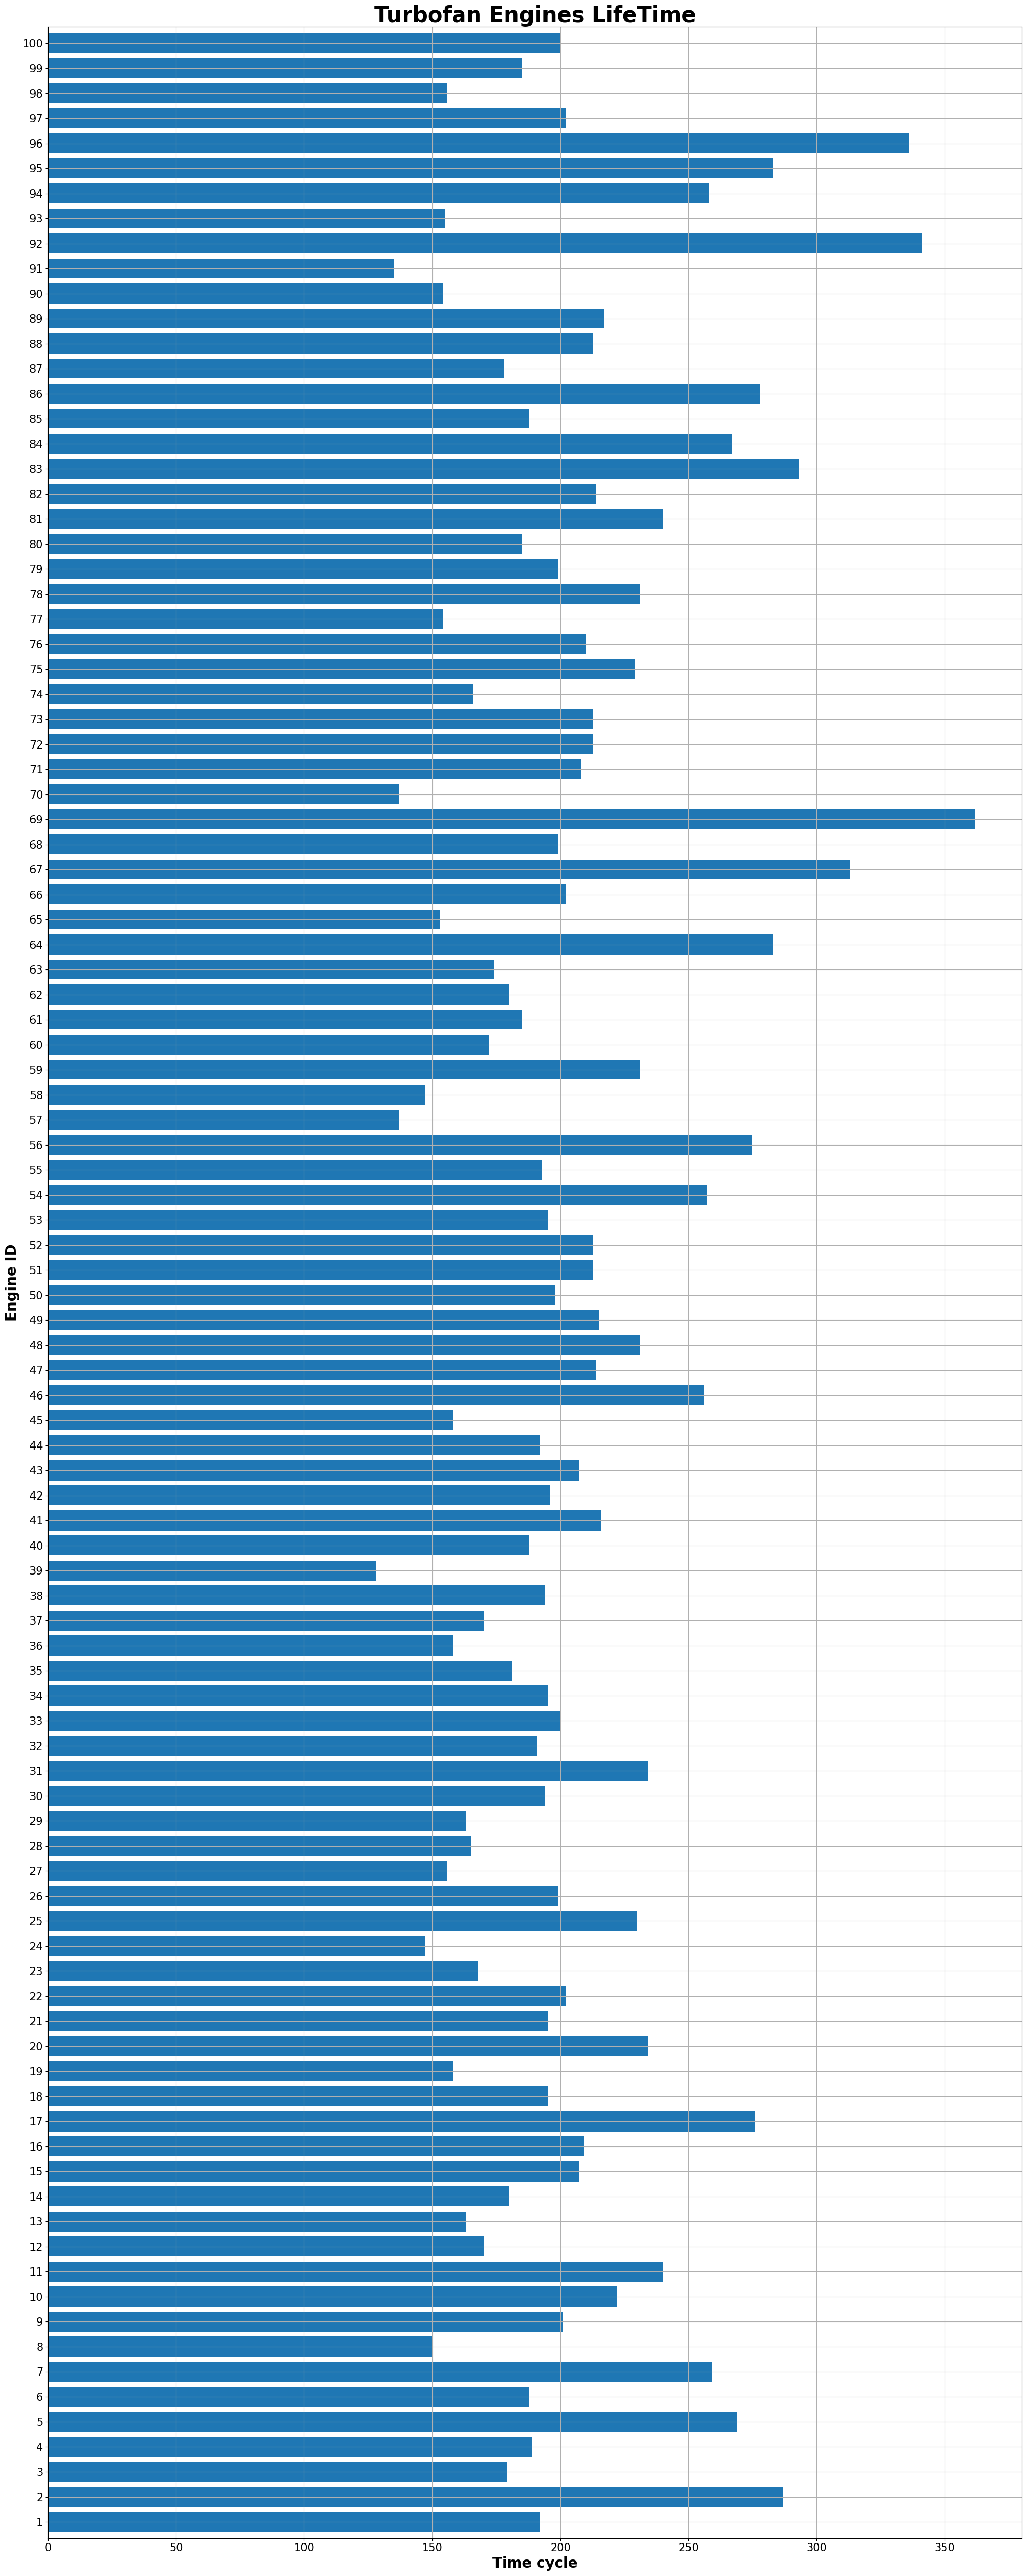

In [ ]:
# [11. 엔진별 수명 시각화]
# - 쓰임새: 각 엔진이 최대 몇 사이클까지 작동했는지 시각적으로 확인합니다.
# - 적용이유: 데이터셋에 포함된 엔진들의 수명 분포를 파악하여, 조기 고장 엔진이 있는지, 수명이 다한 엔진이 있는지 확인합니다.
# - 변경내용: 가로 막대 그래프가 생성되어 엔진 번호와 최대 작동 사이클이 표시됩니다.

max_time_cycles=train_df[['unit_number','time_in_cycles']].groupby('unit_number').max()
plt.figure(figsize=(20,50))
ax=max_time_cycles['time_in_cycles'].plot(kind='barh',width=0.8, stacked=True,align='center')
plt.title('Turbofan Engines LifeTime',fontweight='bold',size=30)
plt.xlabel('Time cycle',fontweight='bold',size=20)
plt.xticks(size=15)
plt.ylabel('Engine ID',fontweight='bold',size=20)
plt.yticks(size=15)
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 9.444444444444459, 'max time in cycles')

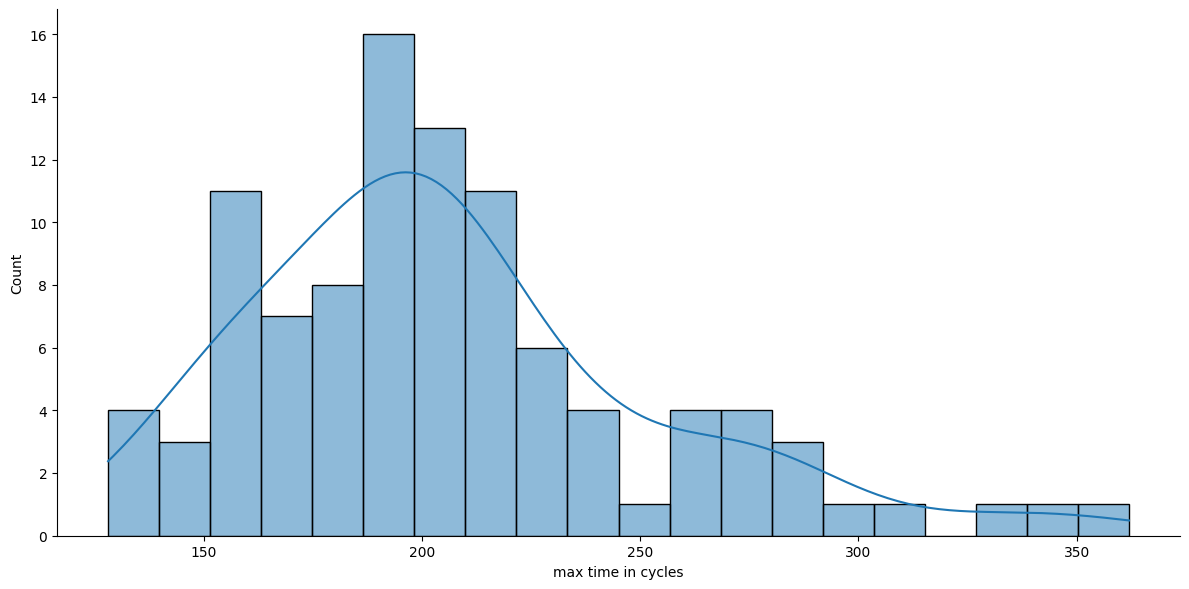

In [ ]:
# [12. 최대 작동 사이클 분포 시각화]
# - 쓰임새: 전체 엔진들의 최대 작동 사이클이 어떤 분포를 이루는지 확인합니다.
# - 적용이유: 데이터셋에 포함된 엔진들의 수명 분포를 파악하여, 조기 고장 엔진이 있는지, 수명이 다한 엔진이 있는지 확인합니다.
# - 변경내용: 히스토그램과 커널 밀도 추정(KDE) 곡선이 함께 표시된 그래프가 생성됩니다.

sns.displot(max_time_cycles['time_in_cycles'],kde=True,bins=20,height=6,aspect=2)
plt.xlabel('max time in cycles')

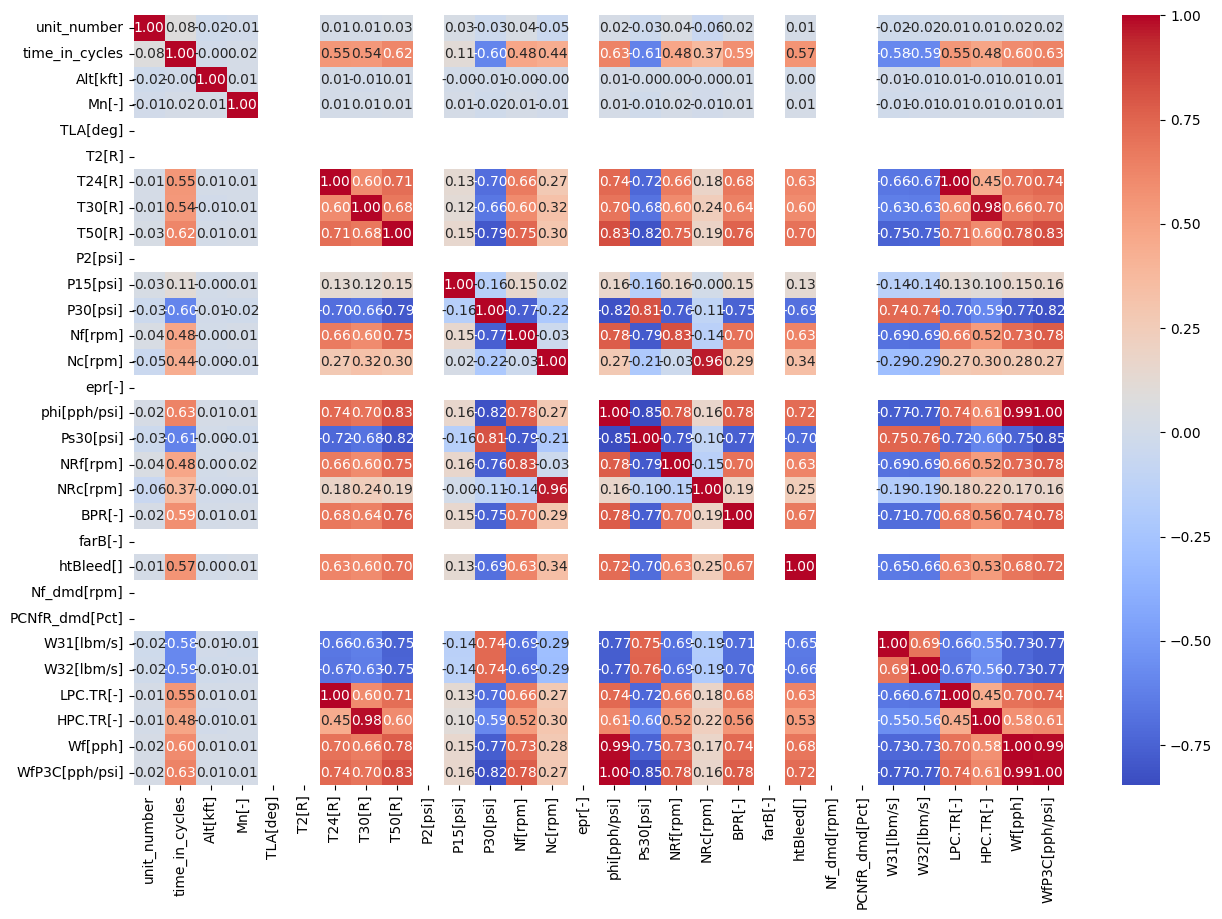

In [ ]:
# [13. 상관관계 히트맵 시각화]
# - 쓰임새: 데이터프레임 내 모든 수치형 컬럼 간의 상관관계를 시각적으로 확인합니다.
# - 적용이유: 어떤 센서들이 서로 관련이 있는지, 또는 특정 센서가 엔진 수명과 얼마나 관련이 있는지 파악하여 피처 엔지니어링이나 모델링에 활용할 수 있습니다.
# - 변경내용: 색상으로 표현된 상관관계 행렬(히트맵)이 생성됩니다.

plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [ ]:
# [14. RUL 컬럼 생성]
# - 쓰임새: 각 엔진별로 '최대 수명 - 현재 시간'을 계산하여 '남은 수명(RUL)' 컬럼을 새로 만듭니다.
# - 적용 이유: 원본 데이터에는 '현재까지 얼마나 운전했는지'만 있고, 우리가 맞춰야 할 '앞으로 얼마나 남았는지'가 없기 때문입니다.
# - 변경 내용: 데이터셋 맨 오른쪽에 인공지능이 맞춰야 할 정답지인 'RUL' 컬럼이 추가됩니다.


# 1. 엔진(unit_number)별로 가장 큰 사이클 번호를 찾습니다.
max_cycle = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']

# 2. 원본 데이터에 최대 수명 정보를 합칩니다.
train_df = train_df.merge(max_cycle, on='unit_number', how='left')

# 3. RUL = 최대 수명 - 현재 사이클
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']

# 사용이 끝난 max_cycle 컬럼은 삭제합니다.
train_df.drop('max_cycle', axis=1, inplace=True)

print("RUL 컬럼 생성 완료!")
train_df[['unit_number', 'time_in_cycles', 'RUL']].head()

RUL 컬럼 생성 완료!


,unit_number,time_in_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


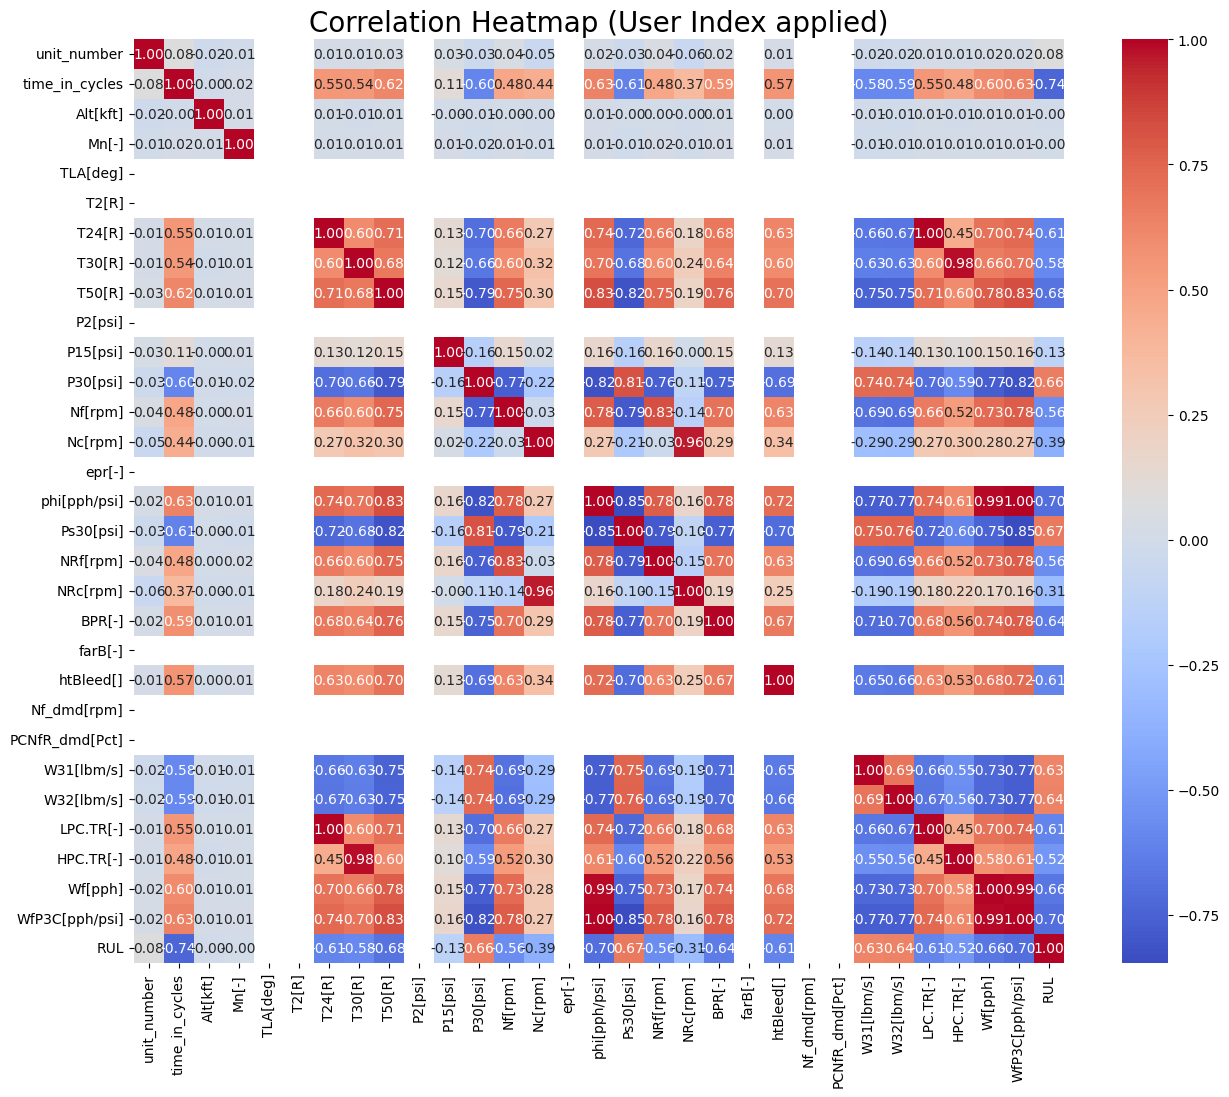

--- RUL과 상관관계가 높은 순서 ---
RUL               1.000000
Ps30[psi]         0.671983
P30[psi]          0.657223
W32[lbm/s]        0.635662
W31[lbm/s]        0.629428
unit_number       0.078753
Mn[-]            -0.001948
Alt[kft]         -0.003198
P15[psi]         -0.128348
NRc[rpm]         -0.306769
Nc[rpm]          -0.390102
HPC.TR[-]        -0.517380
NRf[rpm]         -0.562569
Nf[rpm]          -0.563968
T30[R]           -0.584520
htBleed[]        -0.606154
LPC.TR[-]        -0.606484
T24[R]           -0.606484
BPR[-]           -0.642667
Wf[pph]          -0.660278
T50[R]           -0.678948
phi[pph/psi]     -0.696228
WfP3C[pph/psi]   -0.696228
time_in_cycles   -0.736241
TLA[deg]               NaN
T2[R]                  NaN
P2[psi]                NaN
epr[-]                 NaN
farB[-]                NaN
Nf_dmd[rpm]            NaN
PCNfR_dmd[Pct]         NaN
Name: RUL, dtype: float64


In [ ]:
# [15. 상관관계 계산 (숫자 데이터만!)]
# - 쓰임새: 데이터프레임 내 모든 수치형 컬럼 간의 상관관계를 시각적으로 확인합니다.
# - 적용이유: 어떤 센서들이 서로 관련이 있는지, 또는 특정 센서가 엔진 수명과 얼마나 관련이 있는지 파악하여 피처 엔지니어링이나 모델링에 활용할 수 있습니다.
# - 변경내용: 색상으로 표현된 상관관계 행렬(히트맵)이 생성됩니다.

plt.figure(figsize=(15, 12))

# RUL과 센서들 간의 상관관계만 뽑아서 보기 좋게 정렬합니다.
correlations = train_df.corr(numeric_only=True)['RUL'].sort_values(ascending=False)

# 히트맵 그리기
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (User Index applied)', fontsize=20)
plt.show()

print("--- RUL과 상관관계가 높은 순서 ---")
print(correlations)

In [ ]:
# [16. 데이터 정제 - 노이즈 변수 및 오차 제거]
# - 쓰임새: 값이 변하지 않는 상수 컬럼(표준편차 0)을 삭제하고, 컴퓨터 연산 오차(부동소수점)를 다듬습니다.
# - 적용 이유: 변하지 않는 값은 학습에 도움이 안 되고 계산 속도만 늦추기 때문입니다.
# - 변경 내용: 학습 효율이 떨어지는 불필요한 데이터가 삭제되어 데이터가 가벼워지고 깨끗해집니다.

# 1. 🔍 값이 변하지 않는(분산이 0인) 무의미한 컬럼 자동 추출
constant_columns = [col for col in train_df.columns if train_df[col].nunique() <= 1]

# 2. 📝 자동으로 찾은 고정값 컬럼에 'sensor_6'와 'op_setting_3'를 추가
cols_to_drop = list(set(constant_columns + ['sensor_6', 'op_setting_3']))

# 3. ✂️ 데이터프레임에서 불필요한 컬럼 삭제 실행
train_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"❌ 삭제된 컬럼 목록: {cols_to_drop}")
print(f"✅ 남은 컬럼 개수: {len(train_df.columns)}개")
print(f"📊 현재 컬럼 목록: {train_df.columns.tolist()}")

❌ 삭제된 컬럼 목록: ['farB[-]', 'epr[-]', 'condition', 'PCNfR_dmd[Pct]', 'T2[R]', 'sensor_6', 'op_setting_3', 'Nf_dmd[rpm]', 'P2[psi]', 'TLA[deg]']
✅ 남은 컬럼 개수: 24개
📊 현재 컬럼 목록: ['unit_number', 'time_in_cycles', 'Alt[kft]', 'Mn[-]', 'T24[R]', 'T30[R]', 'T50[R]', 'P15[psi]', 'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 'phi[pph/psi]', 'Ps30[psi]', 'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 'htBleed[]', 'W31[lbm/s]', 'W32[lbm/s]', 'LPC.TR[-]', 'HPC.TR[-]', 'Wf[pph]', 'WfP3C[pph/psi]', 'RUL']


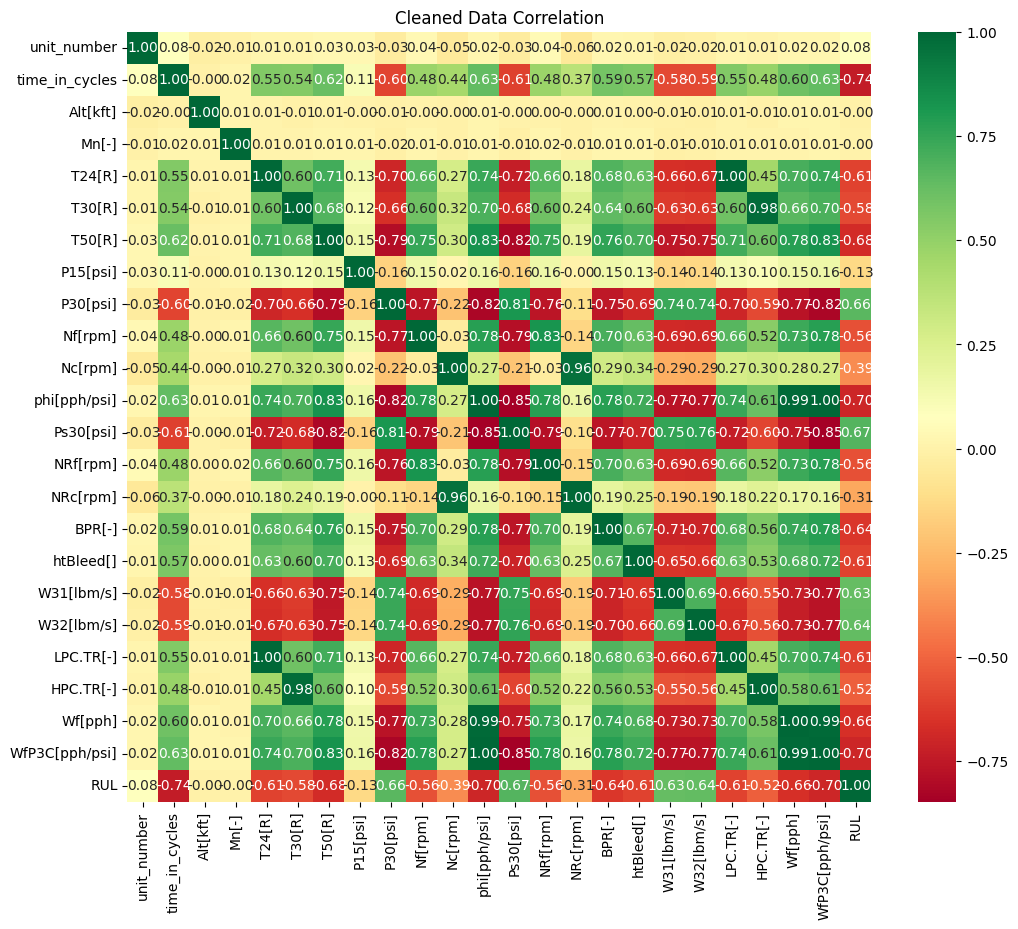

In [ ]:
# [17. 데이터 정제 - 노이즈 변수 및 오차 제거]
# - 쓰임새: 값이 변하지 않는 상수 컬럼(표준편차 0)을 삭제하고, 컴퓨터 연산 오차(부동소수점)를 다듬습니다.
# - 적용 이유: 변하지 않는 값은 학습에 도움이 안 되고 계산 속도만 늦추기 때문입니다.
# - 변경 내용: 학습 효율이 떨어지는 불필요한 데이터가 삭제되어 데이터가 가벼워지고 깨끗해집니다.

plt.figure(figsize=(12, 10))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Cleaned Data Correlation")
plt.show()

In [ ]:
# [18. 이동평균을 이용한 피처 엔지니어링]
# - 쓰임새: 최근 5개 시점의 데이터 평균을 구하는 '이동 평균(Moving Average)' 기법을 적용합니다.
# - 적용 이유: 센서 데이터는 미세한 진동(노이즈)이 심해, 그대로 사용하면 AI가 패턴을 찾기 어렵습니다. 노이즈를 지우고 '경향성'을 살리기 위함입니다.
# - 변경 내용: 심하게 튀던 그래프가 부드러운 곡선으로 바뀌며, 고장 시점에 따른 센서의 상승/하락 추세가 선명해집니다.


# 1. 🔍 분석 대상 센서 리스트 (상관관계가 높았던 주요 센서들)
main_sensors = [
    'T24[R]', 'T30[R]', 'T50[R]', 'P30[psi]', 'Nf[rpm]', 
    'Nc[rpm]', 'Ps30[psi]', 'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 
    'W31[lbm/s]', 'W32[lbm/s]'
]

window_size = 5

# 2. 🌊 5개 사이클씩 묶어서 평균 계산 (이동 평균)
for s in main_sensors:
    if s in train_df.columns:
        # A. 이동 평균 (Moving Average)
        train_df[f'{s}_avg'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).mean())
        
        # B. 표준편차 (Rolling Std)
        train_df[f'{s}_std'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).std())
        
        # C. 변화량 (Difference)
        train_df[f'{s}_diff'] = train_df.groupby('unit_number')[s].transform(lambda x: x.diff(periods=window_size))

# 3. 결측치 처리 (NaN 제거)
train_df = train_df.bfill()

print("✅ 평균(_avg), 표준편차(_std), 기울기(_diff) 생성 및 결측치 처리 완료!")

✅ 평균(_avg), 표준편차(_std), 기울기(_diff) 생성 및 결측치 처리 완료!


In [ ]:
# [19. 누적 성능 변화량 계산]
# - 쓰임새: "지금까지 비행하면서 성능이 얼마나 나빠졌는가?"를 수치화합니다.
# - 적용 이유: 엔진은 시간이 지날수록 마모되어 성능이 떨어집니다. 이 '누적된 손상도'가 고장을 예측하는 가장 강력한 신호입니다.
# - 변경 내용: 각 센서별로 '최고 성능(최소값)'을 기록해두고, 현재 성능과의 차이를 계산하여 새로운 피처로 추가합니다.


# 1. 📉 "가장 좋았을 때보다 얼마나 변했나?" 계산
for sensor in main_sensors:
    if sensor in train_df.columns:
        # 현재까지의 최대값 찾기
        cum_max = train_df.groupby('unit_number')[sensor].cummax()
        # 최대값과 현재값의 차이 계산
        train_df[f'{sensor}_diff'] = cum_max - train_df[sensor]

# 2. 🛠️ 앞부분에 생기는 빈칸(NaN) 채우기
train_df = train_df.infer_objects(copy=False).fillna(method='bfill')

print("✅ 성능 변화량(_diff) 변수 생성 완료!")
print(train_df.head())

✅ 성능 변화량(_diff) 변수 생성 완료!
   unit_number  time_in_cycles  Alt[kft]   Mn[-]  T24[R]   T30[R]   T50[R]  \
0            1               1   -0.0007 -0.0004  641.82  1589.70  1400.60   
1            1               2    0.0019 -0.0003  642.15  1591.82  1403.14   
2            1               3   -0.0043  0.0003  642.35  1587.99  1404.20   
3            1               4    0.0007  0.0000  642.35  1582.79  1401.87   
4            1               5   -0.0019 -0.0002  642.37  1582.85  1406.22   

   P15[psi]  P30[psi]  Nf[rpm]  ...  NRc[rpm]_diff  BPR[-]_avg  BPR[-]_std  \
0     21.61    554.36  2388.06  ...           0.00     8.41334    0.025953   
1     21.61    553.75  2388.04  ...           7.13     8.41334    0.025953   
2     21.61    554.26  2388.08  ...           5.39     8.41334    0.025953   
3     21.61    554.45  2388.11  ...           4.79     8.41334    0.025953   
4     21.61    554.00  2388.06  ...           4.82     8.41334    0.025953   

   BPR[-]_diff  W31[lbm/s]_avg  W31[

C:\Users\yuzhd\AppData\Local\Temp\ipykernel_28580\2267158483.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.infer_objects(copy=False).fillna(method='bfill')


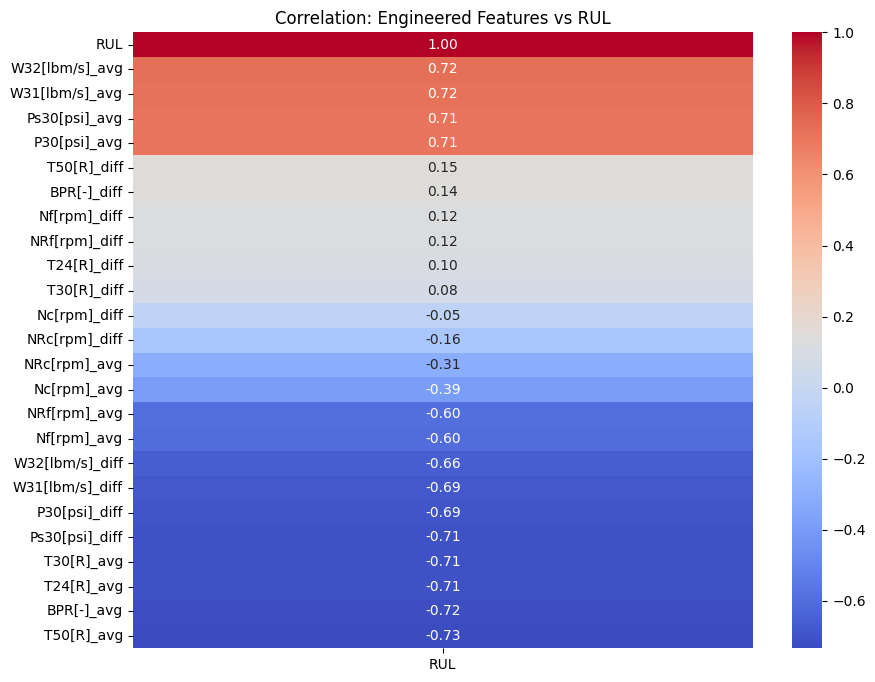

In [ ]:
# [20. 피처 엔지니어링 결과 시각화 및 상관관계 분석]
# - 쓰임새: 새로 만든 '평균(avg)'과 '변화량(diff)' 피처가 실제로 RUL과 얼마나 관련이 있는지 시각적으로 확인합니다.
# - 적용 이유: 상관관계가 높을수록 해당 피처가 고장 예측에 유용하다는 뜻이므로, 모델 학습 시 우선순위를 높일 수 있습니다.
# - 변경 내용: 히트맵을 통해 어떤 센서의 어떤 변화가 고장과 밀접한지 한눈에 파악할 수 있습니다.

new_cols = [col for col in train_df.columns if '_avg' in col or '_diff' in col] + ['RUL']
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[new_cols].corr(numeric_only=True)[['RUL']].sort_values(by='RUL', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Engineered Features vs RUL")
plt.show()

In [ ]:
# [21. 요약 통계량 보기]
# - 쓰임새: 새로 만든 피처들의 분포와 중심 경향성을 확인합니다.
# - 적용 이유: 평균, 표준편차, 최소/최대값 등을 통해 데이터의 특성을 파악하고, 스케일링이나 이상치 탐지의 기초 자료로 활용합니다.
# - 변경 내용: describe() 메서드를 사용하여 요약 통계량을 출력합니다.

train_df[new_cols].describe()

,T24[R]_avg,T24[R]_diff,T30[R]_avg,T30[R]_diff,T50[R]_avg,T50[R]_diff,P30[psi]_avg,P30[psi]_diff,Nf[rpm]_avg,Nf[rpm]_diff,...,NRf[rpm]_diff,NRc[rpm]_avg,NRc[rpm]_diff,BPR[-]_avg,BPR[-]_diff,W31[lbm/s]_avg,W31[lbm/s]_diff,W32[lbm/s]_avg,W32[lbm/s]_diff,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,...,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,642.668087,0.580184,1590.373861,7.696182,1408.672594,7.160707,553.392204,1.511897,2388.094904,0.056491,...,0.056608,8143.459273,6.976453,8.441129,0.038046,38.821149,0.340436,23.292580,0.204149,107.807862
std,0.409755,0.336973,4.851395,4.437970,8.021749,4.486557,0.786760,0.871978,0.063989,0.034600,...,0.034962,18.070825,5.363259,0.032036,0.022770,0.152360,0.184717,0.091513,0.110087,68.880990
min,641.616000,0.000000,1576.244000,0.000000,1390.278000,0.000000,550.810000,0.000000,2387.954000,0.000000,...,0.000000,8103.466000,0.000000,8.367020,0.000000,38.326000,0.000000,23.011400,0.000000,0.000000
25%,642.366000,0.340000,1586.876000,4.515000,1402.644000,3.790000,552.936000,0.900000,2388.046000,0.030000,...,0.030000,8133.368000,3.220000,8.416800,0.021200,38.730000,0.210000,23.238880,0.127400,51.000000
50%,642.624000,0.570000,1589.756000,7.610000,1407.704000,7.040000,553.460000,1.380000,2388.092000,0.060000,...,0.060000,8140.482000,6.350000,8.437680,0.037700,38.838000,0.320000,23.301560,0.191900,103.000000
75%,642.918000,0.810000,1593.179000,10.760000,1413.481000,10.250000,553.996000,2.000000,2388.134000,0.080000,...,0.080000,8147.788000,9.650000,8.459960,0.053700,38.934000,0.450000,23.360620,0.269100,155.000000
max,644.020000,1.870000,1608.070000,25.980000,1432.984000,25.990000,555.174000,5.180000,2388.326000,0.210000,...,0.200000,8281.152000,43.730000,8.542420,0.129800,39.186000,1.210000,23.507160,0.694200,361.000000


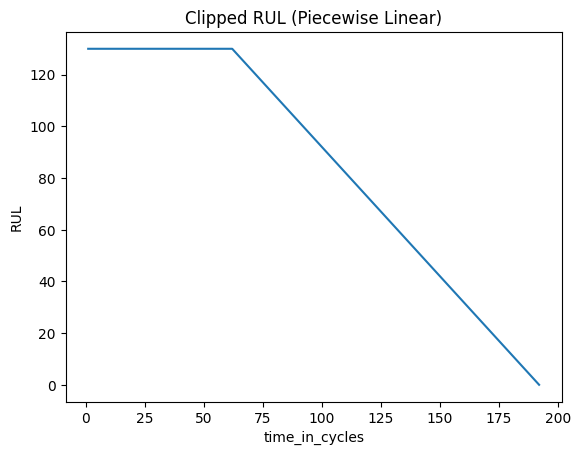

In [ ]:
# [22. RUL 클리핑 (Piecewise Linear)]
# - 쓰임새: RUL의 최대값을 특정 값(예: 130)으로 제한하여 모델이 초반에 헷갈리지 않게 합니다.
# - 적용 이유: 실제 비행 데이터에서는 고장 직전까지 RUL이 거의 선형적으로 감소하다가 마지막에 급격히 떨어지는 경향이 있습니다. 이를 모델에 반영하기 위해 일정 주기 이상은 최대값으로 고정합니다.
# - 변경 내용: apply 함수를 사용하여 RUL 값이 130보다 크면 130으로 변경

train_df['RUL'] = train_df['RUL'].apply(lambda x: 130 if x > 130 else x)

sns.lineplot(data=train_df[train_df['unit_number']==1], x='time_in_cycles', y='RUL')
plt.title("Clipped RUL (Piecewise Linear)")
plt.show()

In [ ]:
# [23. 이동 평균 및 변화량, 상호작용 피처 생성]
# - 쓰임새: 센서 데이터의 노이즈를 줄이고(이동 평균), 변화 추세(변화량)와 센서 간의 관계(상호작용)를 파악합니다.
# - 적용 이유: 고장 예측 시점의 단순한 수치뿐만 아니라, 최근의 변화 추세와 다른 센서와의 복합적인 상태를 고려해야 더 정확한 예측이 가능합니다.
# - 변경 내용: rolling().mean(), rolling().std(), diff(), 그리고 T24와 P30의 비율 계산

exclude_cols = ['unit_number', 'time_in_cycles', 'condition', 'RUL']

# 2. 현재 데이터프레임에서 실제 센서 컬럼들만 리스트로 만듭니다.
# (숫자형 데이터이면서 제외 목록에 없는 컬럼만 추출)
# 1. 계산 대상 센서 리스트 (기존 변수 활용)
actual_sensors = [c for c in train_df.columns if c in col_names and c not in index_names + setting_names]

window_size = 5

for s in actual_sensors:
    # (기존) 이동 평균 및 표준편차
    train_df[f'{s}_avg'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).mean())
    train_df[f'{s}_std'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).std())
    
    # (추가 1) 기울기(Gradient): 5사이클 전과 현재의 차이
    # "얼마나 빨리 변하고 있는가"를 측정합니다.
    train_df[f'{s}_diff'] = train_df.groupby('unit_number')[s].transform(lambda x: x.diff(periods=window_size))

# (추가 2) 상호작용(Interaction): 온도(T24)와 압력(P30)의 비율
# 엔진의 효율 저하를 더 민감하게 포착합니다. (컬럼명이 존재할 경우에만 생성)
if 'T24[R]' in train_df.columns and 'P30[psi]' in train_df.columns:
    train_df['T24_P30_ratio'] = train_df['T24[R]'] / (train_df['P30[psi]'] + 1e-9)

# 결측치 채우기
train_df = train_df.bfill()

print(f"✅ 모든 센서에 대한 이동 평균(_avg) 변수 생성 완료!")
print(f"현재 총 컬럼 수: {len(train_df.columns)}개")

✅ 모든 센서에 대한 이동 평균(_avg) 변수 생성 완료!
현재 총 컬럼 수: 61개


In [ ]:
# [24. 학습 데이터 준비 (Feature Selection)]
# - 쓰임새: 모델이 학습할 피처(Feature)와 타겟(Target)을 분리하고, 불필요한 컬럼을 제외합니다.
# - 적용 이유: 'unit_number'나 'time_in_cycles' 같은 ID 정보는 예측과 관련이 없으므로 학습에서 제외해야 합니다.
# - 변경 내용: exclude 리스트를 정의하여 학습에 사용할 컬럼만 선택


# 1. 원본 센서들 + 이동평균 센서들만 리스트로 만들기
# 'unit_number', 'time_in_cycles', 'RUL' 처럼 공부하면 안 되는 것들을 제외합니다.
exclude = ['unit_number', 'time_in_cycles', 'RUL', 'condition']
target_sensors = [c for c in train_df.columns if c not in exclude]

print(f"✅ 모델이 공부할 총 변수 개수: {len(target_sensors)}개")

✅ 모델이 공부할 총 변수 개수: 58개


C:\Users\yuzhd\AppData\Local\Temp\ipykernel_28580\3737342300.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plt.plot(unit_1['time_in_cycles'], unit_1['P30[psi]_avg'].fillna(method='bfill'), label='Moving Average', color='red', linewidth=2)


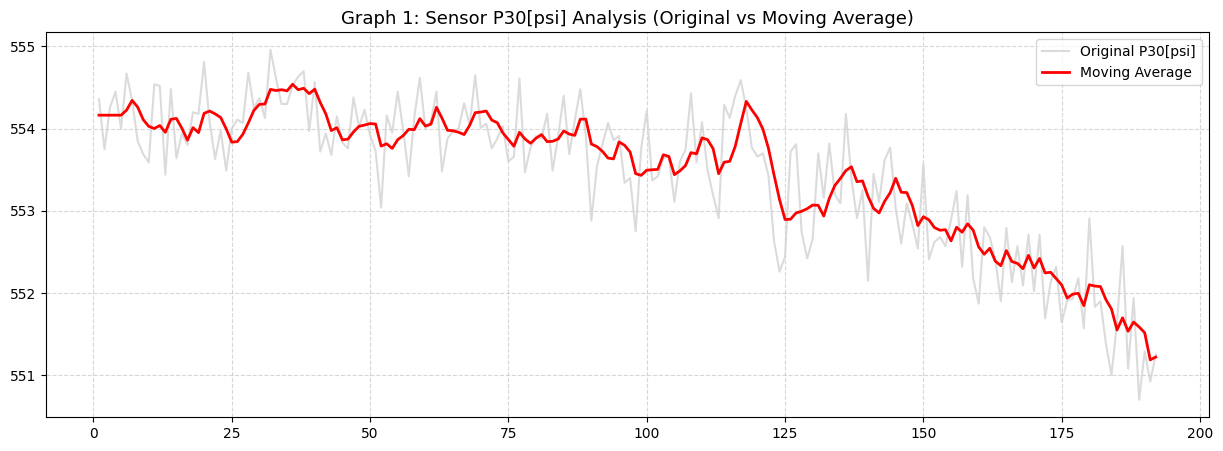

C:\Users\yuzhd\AppData\Local\Temp\ipykernel_28580\3737342300.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plt.plot(unit_1['time_in_cycles'], unit_1['T24[R]_avg'].fillna(method='bfill'), label='Moving Average', color='blue', linewidth=2)


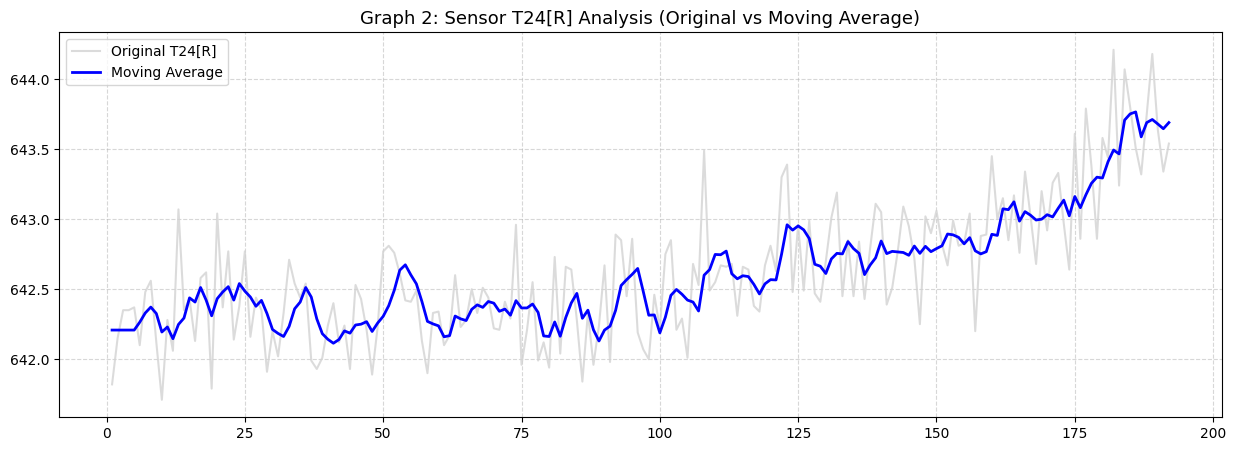

In [ ]:
# [25. 이동평균 시각화]
# - 쓰임새: 이동평균이 원본 데이터의 노이즈를 얼마나 잘 줄였는지 시각적으로 확인합니다.
# - 적용 이유: 그래프를 통해 이동평균이 실제로 더 부드러운 추세를 보여주는지 확인하여, 피처 생성의 효과를 검증합니다.
# - 변경 내용: unit_number가 1인 데이터만 추출하여 원본 데이터와 이동평균 데이터를 함께 그래프로 그림
#윈도우 사이즈 5로 이동평균 계산

# 1. 데이터 추출
unit_1 = train_df[train_df['unit_number'] == 1].copy()

# --- 첫 번째 그래프: P30[psi] 상세 분석 --- # 원본 데이터 (회색)
plt.figure(figsize=(15, 5))
plt.plot(unit_1['time_in_cycles'], unit_1['P30[psi]'], label='Original P30[psi]', color='lightgray', alpha=0.8)
plt.plot(unit_1['time_in_cycles'], unit_1['P30[psi]_avg'].fillna(method='bfill'), label='Moving Average', color='red', linewidth=2)
plt.title('Graph 1: Sensor P30[psi] Analysis (Original vs Moving Average)', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- 두 번째 그래프: T24[R] 상세 분석 (아까 sensor_11과 같은 것) --- # 원본 데이터 (회색)
plt.figure(figsize=(15, 5))
plt.plot(unit_1['time_in_cycles'], unit_1['T24[R]'], label='Original T24[R]', color='lightgray', alpha=0.8)
plt.plot(unit_1['time_in_cycles'], unit_1['T24[R]_avg'].fillna(method='bfill'), label='Moving Average', color='blue', linewidth=2)
plt.title('Graph 2: Sensor T24[R] Analysis (Original vs Moving Average)', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# [26. 이동평균과 표준편차 생성]
# - 쓰임새: 이동평균은 데이터의 노이즈를 줄여 추세를 명확하게 하고, 표준편차는 데이터의 변동성(불안정성)을 수치화합니다.
# - 적용 이유: 두 피처를 함께 사용하면 모델이 엔진의 '평균적인 상태'와 '현재 얼마나 불안정한지'를 동시에 파악할 수 있어 예측 성능이 향상됩니다.
# - 변경 내용: 기존 센서 컬럼들에 대해 이동평균(_avg)과 표준편차(_std)를 계산하여 데이터프레임에 추가

# 1. 계산에서 제외할 컬럼 (기본 정보 및 정답)
exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'condition']

# 2. 실제 센서 컬럼들만 리스트로 추출
# (현재 train_df에 존재하는 컬럼 중 제외 목록에 없는 것들)
actual_sensors = [c for c in train_df.columns if c not in exclude_cols and '_avg' not in c and '_std' not in c]

window_size = 5

for s in actual_sensors:
    # A. 이동 평균 (Rolling Mean) 생성
    train_df[f'{s}_avg'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).mean())
    
    # B. 표준편차 (Rolling Std) 생성 👈 이게 추가된 부분!
    train_df[f'{s}_std'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).std())

# 3. 결측치 채우기 (초반 5개 행의 NaN 제거)
train_df = train_df.bfill()

print(f"✅ {len(actual_sensors)}개 센서에 대해 평균(_avg)과 표준편차(_std) 생성 완료!")

✅ 34개 센서에 대해 평균(_avg)과 표준편차(_std) 생성 완료!


In [ ]:
# [27. 데이터 스케일링 - 단위 통일]
# - 쓰임새: 모든 센서 데이터의 범위를 0과 1 사이로 압축합니다.
# - 적용 이유: 온도(600도)와 압력(15psi)처럼 단위 차이가 크면, 모델이 숫자가 큰 온도만 중요하다고 착각할 수 있습니다. 공정한 학습을 위해 단위를 맞춥니다.
# - 변경 내용: 서로 제각각이던 데이터의 크기가 0~1 사이로 균일하게 맞춰집니다.

exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'condition']
scaling_cols = [c for c in train_df.columns if c not in exclude_cols and train_df[c].dtype != 'object']

scaler = MinMaxScaler()
train_df[scaling_cols] = scaler.fit_transform(train_df[scaling_cols])

print(f"✨ 스케일링 완료! 대상 컬럼 수: {len(scaling_cols)}개")
print(f"📋 첫 5개 스케일링 컬럼 예시: {scaling_cols[:5]}")

✨ 스케일링 완료! 대상 컬럼 수: 102개
📋 첫 5개 스케일링 컬럼 예시: ['Alt[kft]', 'Mn[-]', 'T24[R]', 'T30[R]', 'T50[R]']


In [ ]:
# [28. 엔진 상태 세분화]
# - 쓰임새: 엔진의 상태를 '정상', '약간 불안정', '심하게 불안정' 등 여러 단계로 나눕니다.
# - 적용 이유: 단순한 수치(예: 100도)만 보는 것이 아니라, '평소보다 얼마나 변했는가'를 기준으로 엔진의 건강 상태를 더 정확하게 진단할 수 있습니다.
# - 변경 내용: is_vibrating(떨림 여부)과 stress_index(종합 위험 지수)라는 새로운 컬럼이 추가됩니다.


std_mean = train_df['T24[R]_std'].mean()

# 평균보다 떨림이 크면 1(위험 징후), 낮으면 0(안정)으로 세분화
train_df['is_vibrating'] = (train_df['T24[R]_std'] > std_mean).astype(int)

#(선택사항) 여러 센서의 떨림을 합쳐서 '종합 위험 지수' 만들기
# 떨림이 발생하는 센서가 많을수록 숫자가 높아집니다.
std_cols = [c for c in train_df.columns if '_std' in c]
train_df['stress_index'] = train_df[std_cols].gt(train_df[std_cols].mean()).sum(axis=1)

print("✅ 엔진 상태 세분화 인덱스(is_vibrating, stress_index) 생성 완료!")

✅ 엔진 상태 세분화 인덱스(is_vibrating, stress_index) 생성 완료!


C:\Users\yuzhd\AppData\Local\Temp\ipykernel_28580\3372075854.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['is_vibrating'] = (train_df['T24[R]_std'] > std_mean).astype(int)
C:\Users\yuzhd\AppData\Local\Temp\ipykernel_28580\3372075854.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['stress_index'] = train_df[std_cols].gt(train_df[std_cols].mean()).sum(axis=1)


In [ ]:
# [29. 학습 데이터셋 구성]
# - 쓰임새: 모델이 공부할 '문제지(X)'와 '정답지(y)'를 만듭니다.
# - 적용 이유: 엔진 번호나 정답(RUL) 같은 불필요한 정보가 섞여 있으면 모델이 헷갈리기 때문에, 학습에 꼭 필요한 센서 데이터만 골라냅니다.
# - 변경 내용: features 리스트에 학습에 사용할 컬럼명들이 저장됩니다.

# 정답(RUL)이나 엔진번호처럼 학습에 쓰면 안 되는 것들을 제외합니다.
exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'condition']
features = [c for c in train_df.columns if c not in exclude_cols]

print(f"✅ 학습에 사용될 피처 개수: {len(features)}개")
print(f"📊 포함된 피처들: {features}")

✅ 학습에 사용될 피처 개수: 104개
📊 포함된 피처들: ['Alt[kft]', 'Mn[-]', 'T24[R]', 'T30[R]', 'T50[R]', 'P15[psi]', 'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 'phi[pph/psi]', 'Ps30[psi]', 'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 'htBleed[]', 'W31[lbm/s]', 'W32[lbm/s]', 'LPC.TR[-]', 'HPC.TR[-]', 'Wf[pph]', 'WfP3C[pph/psi]', 'T24[R]_avg', 'T24[R]_std', 'T24[R]_diff', 'T30[R]_avg', 'T30[R]_std', 'T30[R]_diff', 'T50[R]_avg', 'T50[R]_std', 'T50[R]_diff', 'P30[psi]_avg', 'P30[psi]_std', 'P30[psi]_diff', 'Nf[rpm]_avg', 'Nf[rpm]_std', 'Nf[rpm]_diff', 'Nc[rpm]_avg', 'Nc[rpm]_std', 'Nc[rpm]_diff', 'Ps30[psi]_avg', 'Ps30[psi]_std', 'Ps30[psi]_diff', 'NRf[rpm]_avg', 'NRf[rpm]_std', 'NRf[rpm]_diff', 'NRc[rpm]_avg', 'NRc[rpm]_std', 'NRc[rpm]_diff', 'BPR[-]_avg', 'BPR[-]_std', 'BPR[-]_diff', 'W31[lbm/s]_avg', 'W31[lbm/s]_std', 'W31[lbm/s]_diff', 'W32[lbm/s]_avg', 'W32[lbm/s]_std', 'W32[lbm/s]_diff', 'T24_P30_ratio', 'Alt[kft]_avg', 'Alt[kft]_std', 'Mn[-]_avg', 'Mn[-]_std', 'P15[psi]_avg', 'P15[psi]_std', 'phi[pph/psi]_avg', 'phi[pph/p

In [ ]:
# [30. 데이터 스케일링]
# - 쓰임새: 모든 센서 데이터의 눈높이를 맞춰줍니다.
# - 변경 내용: scaling_cols 리스트에 스케일링할 컬럼명들이 저장됩니다.

train_df[scaling_cols].describe()

,Alt[kft],Mn[-],T24[R],T30[R],T50[R],P15[psi],P30[psi],Nf[rpm],Nc[rpm],phi[pph/psi],...,NRc[rpm]_diff_avg,NRc[rpm]_diff_std,BPR[-]_diff_avg,BPR[-]_diff_std,W31[lbm/s]_diff_avg,W31[lbm/s]_diff_std,W32[lbm/s]_diff_avg,W32[lbm/s]_diff_std,T24_P30_ratio_avg,T24_P30_ratio_std
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,...,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.499490,0.501959,0.443052,0.424746,0.450435,0.980321,0.566459,0.297957,0.195248,0.411410,...,0.170956,0.327167,0.422287,0.350794,0.332280,0.410073,0.352186,0.318438,0.397397,0.360553
std,0.125708,0.244218,0.150618,0.133664,0.151935,0.138898,0.142527,0.107554,0.099089,0.158981,...,0.111073,0.124250,0.160930,0.128982,0.156987,0.147650,0.167577,0.124979,0.179339,0.142402
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.413793,0.333333,0.335843,0.331807,0.339467,1.000000,0.476651,0.227273,0.140761,0.297619,...,0.099604,0.240315,0.308889,0.257431,0.222664,0.304193,0.235659,0.228290,0.259904,0.257106
50%,0.500000,0.500000,0.430723,0.415522,0.435348,1.000000,0.578100,0.287879,0.174684,0.392857,...,0.154212,0.320337,0.418000,0.342850,0.304175,0.401474,0.322700,0.312110,0.380864,0.351070
75%,0.586207,0.750000,0.539157,0.508829,0.545324,1.000000,0.669887,0.363636,0.213991,0.505952,...,0.213231,0.406140,0.530000,0.433697,0.419483,0.506679,0.443401,0.399280,0.501222,0.452147
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


✅ 분석할 센서들을 찾았습니다: ['Alt[kft]', 'Mn[-]', 'T24[R]', 'T30[R]', 'T50[R]']... 등


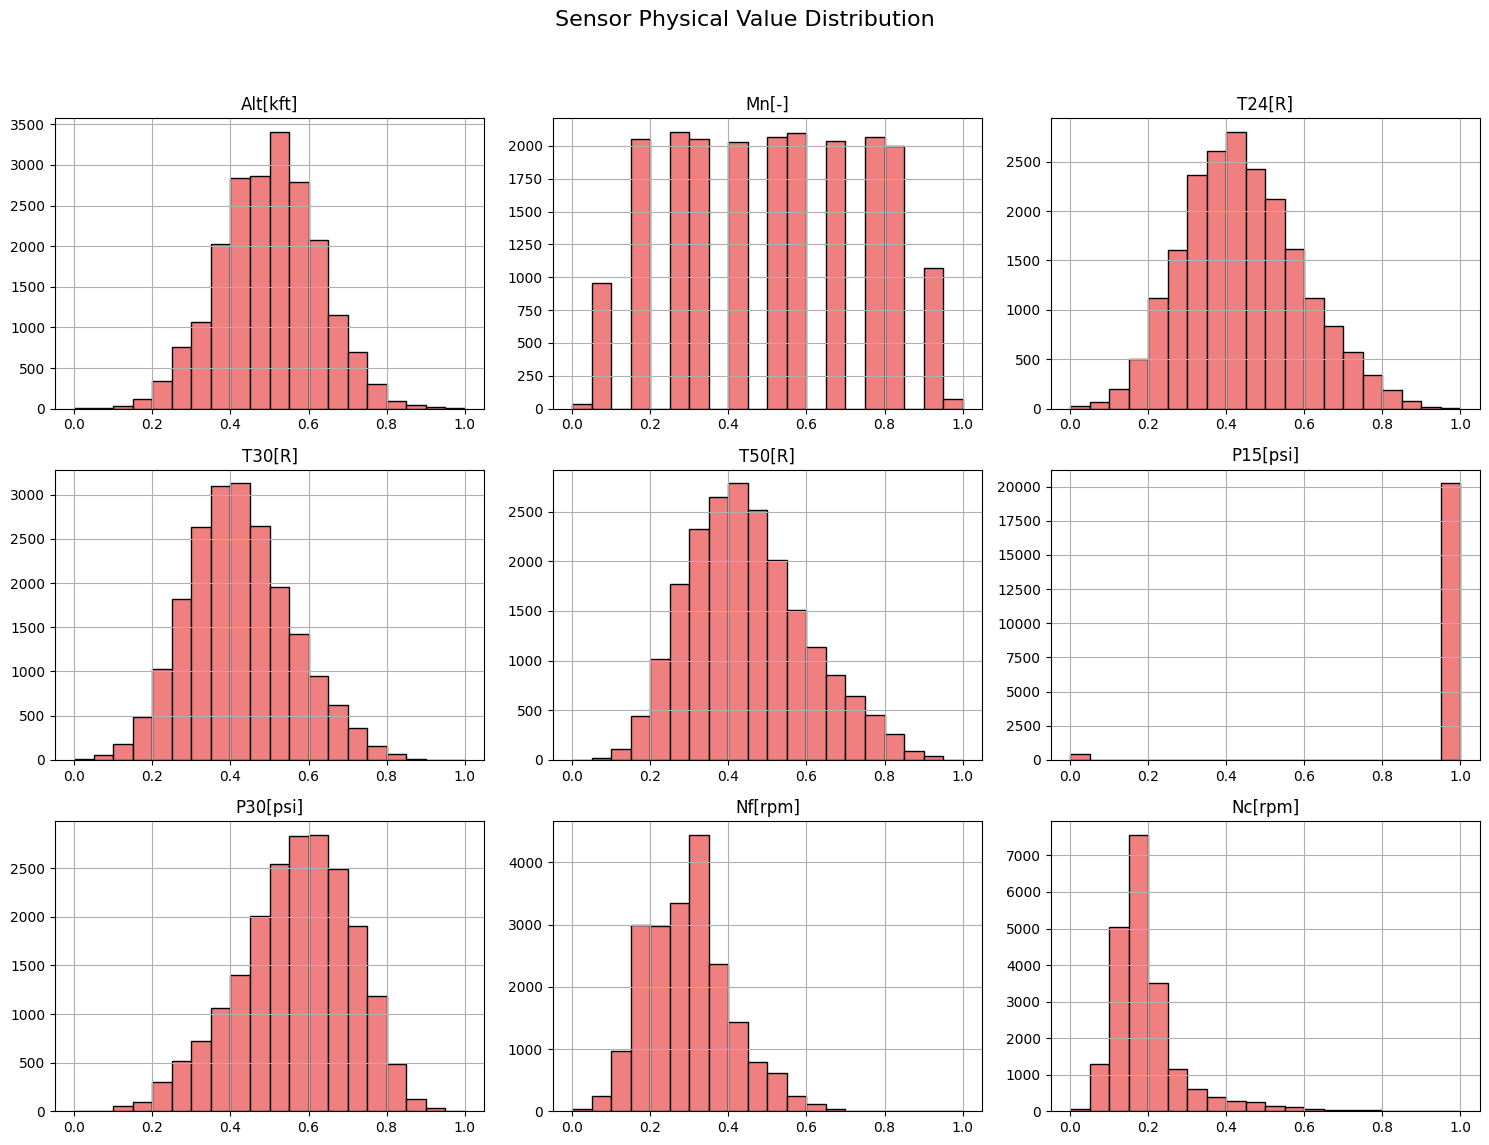

In [ ]:
# [31. 데이터 시각화]
# - 쓰임새: 각 센서가 고장나기 전까지 어떻게 변하는지 눈으로 확인합니다.
# - 적용 이유: 그래프를 보면 '아, 이 센서는 100이 넘어가면 위험하구나' 하는 감을 잡을 수 있습니다.
# - 변경 내용: 히스토그램(막대그래프)을 그려서 데이터 분포를 확인합니다.


# 1. 📋 분석에서 제외할 기본 정보 컬럼들
exclude_cols = ['unit_number', 'time_in_cycles', 'RUL']

# 2. 🔍 나머지 실제 센서 데이터 컬럼들만 쏙 골라내기
actual_sensors = [c for c in train_df.columns if c not in exclude_cols]

print(f"✅ 분석할 센서들을 찾았습니다: {actual_sensors[:5]}... 등")

# 3. 📊 히스토그램 그리기 (상위 9개 센서)
if len(actual_sensors) == 0:
    print("❌ 여전히 컬럼을 찾을 수 없습니다. 데이터 로드 부분을 확인해주세요.")
else:
    # 한 화면에 9개까지 그려서 확인해봅시다
    train_df[actual_sensors[:9]].hist(bins=20, figsize=(15, 12), color='lightcoral', edgecolor='black')
    plt.suptitle("Sensor Physical Value Distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# [32. 데이터 정제]
# - 쓰임새: 결측치나 이상치를 제거하여 데이터 품질을 높입니다.
# - 적용 이유: 결측치가 있으면 모델이 학습을 못하고, 이상치가 있으면 오작동할 수 있습니다.
# - 변경 내용: 결측치를 0으로 채우고, 이상치를 제거합니다.


# 1. 빈 값이 있는지 확인 (0이어야 함)
print("❌ 결측치 개수:\n", train_df.isnull().sum().sum())

# 2. 모든 데이터가 숫자인지 확인 (object가 없어야 함)
print("\n📋 데이터 타입 요약:")
print(train_df.dtypes.value_counts())

❌ 결측치 개수:
 0

📋 데이터 타입 요약:
float64    102
int64        4
int32        1
Name: count, dtype: int64


In [ ]:
# [33. 파생변수 생성]
# - 쓰임새: 기존 데이터만으로는 부족한 정보를 새롭게 만들어냅니다.
# - 적용 이유: 센서 값 자체보다 '변화량'이나 '떨림'이 고장을 더 잘 예측할 수 있기 때문입니다.
# - 변경 내용: 'is_vibrating' 컬럼이 추가되었습니다.

std_threshold = train_df['T24[R]_std'].mean() * 2
train_df['is_vibrating'] = (train_df['T24[R]_std'] > std_threshold).astype(int)

In [ ]:
# [34. 데이터 분할]
# - 쓰임새: 모델을 학습시킬 데이터와 평가할 데이터를 분리합니다.
# - 적용 이유: 같은 엔진으로 학습하고 평가하면 '기계가 외운 것'인지 '진짜 실력'인지 알 수 없기 때문에, 엔진 번호를 기준으로 섞어서 분리합니다.
# - 변경 내용: train_set과 val_set이 생성되었습니다.

gss = GroupShuffleSplit(n_splits=1, train_size=0.80, random_state=42)
train_idx, val_idx = next(gss.split(train_df, groups=train_df['unit_number']))

train_set = train_df.iloc[train_idx]
val_set = train_df.iloc[val_idx]
print(f"✅ 학습용 분할 완료!")
print(f"학습용 엔진: {train_set['unit_number'].nunique()}개, 검증용 엔진: {val_set['unit_number'].nunique()}개")

✅ 학습용 분할 완료!
학습용 엔진: 80개, 검증용 엔진: 20개


In [ ]:
# [35. 피처 선택]
# - 쓰임새: 모델이 학습할 데이터(X)와 정답(y)을 분리합니다.
# - 적용 이유: 'unit_number'나 'RUL' 같은 정답/분류 정보는 모델이 보면 안 되므로 제외합니다.
# - 변경 내용: X_train, y_train, X_val, y_val이 생성되었습니다.


exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'condition']

# 'condition'이 혹시 없을 수도 있으니 안전하게 필터링
features = [c for c in train_df.columns if c not in exclude_cols]

X_train = train_set[features]
y_train = train_set['RUL']
X_val = val_set[features]
y_val = val_set['RUL']

print(f"✅ 학습 준비 완료! 사용된 피처 수: {len(features)}개")

✅ 학습 준비 완료! 사용된 피처 수: 104개


### 모델 팀 결성, 학습, 예측, 평가